# Part A : Linear Regression

# Bike Sharing Dataset Overview

The **Bike Sharing Dataset** contains data collected from a bike rental system over a two-year period (2011–2012). It tracks hourly demand for shared bikes in relation to environmental and seasonal conditions.

The goal is to **predict the number of bike rentals** (`cnt`) based on time, weather, and user behavior variables.

---

## Source:

Available via the UCI Machine Learning Repository:

* [UCI Dataset Page](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset)

---

## Target Variable:

* **cnt** *(numeric)*: Total number of bike rentals (casual + registered) in a given hour.

---

## Features:

| Column Name | Description                                                      | Data Type          |
| ----------- | ---------------------------------------------------------------- | ------------------ |
| instant     | Record index (can be dropped)                                    | *Integer*          |
| season      | Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)                | *Categorical*      |
| yr          | Year (0: 2011, 1: 2012)                                          | *Binary*           |
| mnth        | Month (1 to 12)                                                  | *Categorical*      |
| hr          | Hour of the day (0 to 23)                                        | *Categorical*      |
| holiday     | Whether the day is a holiday                                     | *Binary*           |
| weekday     | Day of the week (0: Sunday, 6: Saturday)                         | *Categorical*      |
| workingday  | Whether the day is a working day                                 | *Binary*           |
| weathersit  | Weather situation (1: Clear, 2: Mist, 3: Light Snow/Rain, etc.)  | *Categorical*      |
| temp        | Normalized temperature (0 to 1 scale)                            | *Numeric (float)*  |
| atemp       | Normalized "feels like" temperature                              | *Numeric (float)*  |
| hum         | Normalized humidity (0 to 1 scale)                               | *Numeric (float)*  |
| windspeed   | Normalized wind speed                                            | *Numeric (float)*  |
| casual      | Count of casual users (do **not** use when predicting `cnt`)     | *Numeric*          |
| registered  | Count of registered users (do **not** use when predicting `cnt`) | *Numeric*          |
| cnt         | **Target**: Total number of rentals (casual + registered)        | **Numeric Target** |

---

### Note on Leakage:

The features `casual` and `registered` **should not be used** when predicting `cnt`, as they are **components of the target variable** and would introduce data leakage.


# **Loading the dataset into a datafarme**

In [87]:
import pandas as pd


df = pd.read_csv("bike_sharing.csv")

print(df.shape)
df


(17379, 16)


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  casual      17379 non-null  int64  
 14  registered  17379 non-null  int64  
 15  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12)
memory usage: 2.1 MB


# **Checking for missing values**

In [89]:
df.isna().sum()

,0
instant,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [90]:
df_clean = df.drop(columns=["instant", "casual", "registered"])
categorical_cols = ["season", "yr", "mnth", "hr", "holiday",
                    "weekday", "workingday", "weathersit"]

df_clean[categorical_cols] = df_clean[categorical_cols].astype("object")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  object 
 1   yr          17379 non-null  object 
 2   mnth        17379 non-null  object 
 3   hr          17379 non-null  object 
 4   holiday     17379 non-null  object 
 5   weekday     17379 non-null  object 
 6   workingday  17379 non-null  object 
 7   weathersit  17379 non-null  object 
 8   temp        17379 non-null  float64
 9   atemp       17379 non-null  float64
 10  hum         17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  cnt         17379 non-null  int64  
dtypes: float64(4), int64(1), object(8)
memory usage: 1.7+ MB


# **Displaying unique values of categorical columns**

In [91]:
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"{col} ({len(unique_vals)} unique): {unique_vals}")
    print('------------------------------------------------')

season (4 unique): [1 2 3 4]
------------------------------------------------
yr (2 unique): [0 1]
------------------------------------------------
mnth (12 unique): [ 1  2  3  4  5  6  7  8  9 10 11 12]
------------------------------------------------
hr (24 unique): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
------------------------------------------------
holiday (2 unique): [0 1]
------------------------------------------------
weekday (7 unique): [6 0 1 2 3 4 5]
------------------------------------------------
workingday (2 unique): [0 1]
------------------------------------------------
weathersit (4 unique): [1 2 3 4]
------------------------------------------------


# **Distribution of target variable**

<Axes: title={'center': 'Histogram of Total Bike Rentals'}, ylabel='Frequency'>

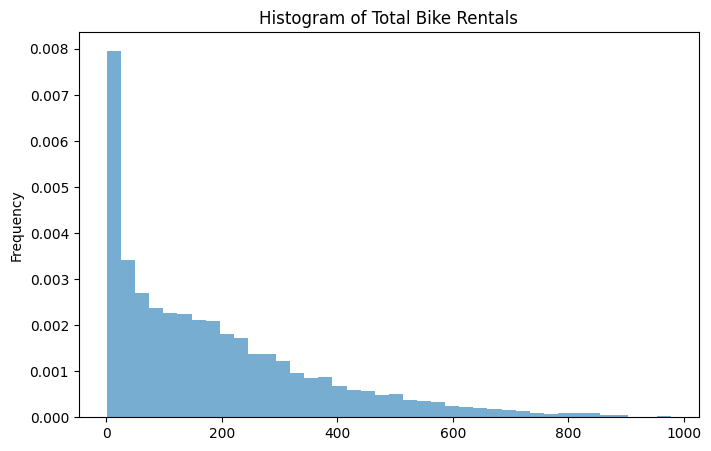

In [92]:
df_clean["cnt"].plot(kind="hist", bins=40, density=True, alpha=0.6, figsize=(8, 5), title="Histogram of Total Bike Rentals")
#df_clean["cnt"].plot(kind="kde", linewidth=2)


* The distribution is highly right-skewed.
* There are many low rental counts and a long tail of high counts.

# **Splitting the dataset into train-test sets**

In [93]:
from sklearn.model_selection import train_test_split

# Drop 'ID' column
X = df_clean.drop(['cnt'], axis=1)  # Features
y = df_clean['cnt']                       # Target column

# Perform train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

# Display shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (13903, 12)
X_test shape: (3476, 12)
y_train shape: (13903,)
y_test shape: (3476,)


# **Linear regression model with categorical variables (a) Integer Encoded (b) One hot Encoded. All numeric features are normalized to have zero mean and standard deviation one.**

In [94]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Split into numeric and categorical
X_train_num = X_train[numeric_cols]
X_test_num = X_test[numeric_cols]

X_train_cat = X_train[categorical_cols]
X_test_cat = X_test[categorical_cols]

# Scale numeric features
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Encode categorical features
encoder = OrdinalEncoder()
X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_test_cat_encoded = encoder.transform(X_test_cat)

# Combine numeric and categorical features
X_train_final = np.hstack((X_train_num_scaled, X_train_cat_encoded))
X_test_final = np.hstack((X_test_num_scaled, X_test_cat_encoded))

# Train linear regression
reg = LinearRegression()
reg.fit(X_train_final, y_train)

# Predict
y_pred = reg.predict(X_test_final)

# Regression Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print metrics
# Print results
print("\n=== Linear Regression with Integer Encoding ===")

print(f"MAE   : {mae:.2f}")
print(f"MSE   : {mse:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"R²    : {r2:.4f}")






from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Split features
X_train_num_oh = X_train[numeric_cols]
X_test_num_oh = X_test[numeric_cols]
X_train_cat_oh = X_train[categorical_cols]
X_test_cat_oh = X_test[categorical_cols]

# Scale numeric features
scaler_oh = StandardScaler()
X_train_num_scaled_oh = scaler_oh.fit_transform(X_train_num_oh)
X_test_num_scaled_oh = scaler_oh.transform(X_test_num_oh)

# One-hot encode categorical features # drop='first'
ohe = OneHotEncoder(handle_unknown='ignore',  sparse_output=False)
X_train_cat_encoded_oh = ohe.fit_transform(X_train_cat_oh)
X_test_cat_encoded_oh = ohe.transform(X_test_cat_oh)

# Combine numeric and categorical features
X_train_final_oh = np.hstack((X_train_num_scaled_oh, X_train_cat_encoded_oh))
X_test_final_oh = np.hstack((X_test_num_scaled_oh, X_test_cat_encoded_oh))

# Train linear regression
reg_oh = LinearRegression()
reg_oh.fit(X_train_final_oh, y_train)

# Predict
y_pred_oh = reg_oh.predict(X_test_final_oh)

# Evaluate
mae_oh = mean_absolute_error(y_test, y_pred_oh)
mse_oh = mean_squared_error(y_test, y_pred_oh)
rmse_oh = np.sqrt(mse_oh)
r2_oh = r2_score(y_test, y_pred_oh)

# Print results
print("\n=== Linear Regression with One-Hot Encoding ===")
print(f"MAE   : {mae_oh:.2f}")
print(f"MSE   : {mse_oh:.2f}")
print(f"RMSE  : {rmse_oh:.2f}")
print(f"R²    : {r2_oh:.4f}")



=== Linear Regression with Integer Encoding ===
MAE   : 104.80
MSE   : 19379.83
RMSE  : 139.21
R²    : 0.3880

=== Linear Regression with One-Hot Encoding ===
MAE   : 74.11
MSE   : 10089.39
RMSE  : 100.45
R²    : 0.6814


# **Showing actual values of target variable `cnt` (Actual_cnt) and its predicted values (Predicted_cnt) when using Linear Regression with Integer encoding for some samples**

In [95]:
df_results_ordinal = X_test.copy()
df_results_ordinal['Actual_cnt'] = y_test.values
df_results_ordinal['Predicted_cnt'] = y_pred


df_sample_ordinal = df_results_ordinal.sample(10, random_state=42)

df_sample_ordinal




,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,Actual_cnt,Predicted_cnt
4848,3,0,7,22,0,1,1,1,0.70,0.6667,0.84,0.0000,125,249.070265
15801,4,1,10,14,0,4,1,1,0.60,0.5909,0.73,0.1343,285,297.953903
3647,2,0,6,21,0,0,0,1,0.64,0.6061,0.73,0.1642,165,224.328124
4738,3,0,7,8,0,4,1,2,0.76,0.7576,0.79,0.1642,381,183.908533
10718,2,1,3,17,0,2,1,1,0.44,0.4394,0.16,0.0000,614,337.676287
9904,1,1,2,17,0,3,1,1,0.52,0.5000,0.32,0.3881,529,320.634131
3944,2,0,6,6,0,6,0,1,0.62,0.5758,0.83,0.1045,27,89.858341
12985,3,1,6,6,0,6,0,1,0.64,0.5758,0.89,0.1642,42,185.293191
12220,2,1,5,9,0,2,1,1,0.72,0.6818,0.70,0.2537,257,255.076079
16097,4,1,11,11,0,4,1,1,0.36,0.3333,0.29,0.3881,171,295.027450


# **Showing actual values of target variable `cnt` (Actual_cnt) and its predicted values (Predicted_cnt) when using Linear Regression with One hot encoding for some samples**

In [96]:
df_results_onehot = X_test.copy()
df_results_onehot['Actual_cnt'] = y_test.values
df_results_onehot['Predicted_cnt'] = y_pred_oh
df_sample_onehot = df_results_onehot.sample(10, random_state=42)
df_sample_onehot

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,Actual_cnt,Predicted_cnt
4848,3,0,7,22,0,1,1,1,0.70,0.6667,0.84,0.0000,125,114.845844
15801,4,1,10,14,0,4,1,1,0.60,0.5909,0.73,0.1343,285,329.952866
3647,2,0,6,21,0,0,0,1,0.64,0.6061,0.73,0.1642,165,157.647986
4738,3,0,7,8,0,4,1,2,0.76,0.7576,0.79,0.1642,381,368.020810
10718,2,1,3,17,0,2,1,1,0.44,0.4394,0.16,0.0000,614,538.242103
9904,1,1,2,17,0,3,1,1,0.52,0.5000,0.32,0.3881,529,485.053040
3944,2,0,6,6,0,6,0,1,0.62,0.5758,0.83,0.1045,27,87.307614
12985,3,1,6,6,0,6,0,1,0.64,0.5758,0.89,0.1642,42,165.282873
12220,2,1,5,9,0,2,1,1,0.72,0.6818,0.70,0.2537,257,338.453667
16097,4,1,11,11,0,4,1,1,0.36,0.3333,0.29,0.3881,171,254.368078


### **The deviation of predicted values from the actual values is smaller with one-hot encoding, while it is larger with integer encoding.**

# **Linear regression is performed with the target variable log-transformed and categorical variables encoded using (a) integer encoding and (b) one-hot encoding. All numeric features are normalized to have zero mean and a standard deviation of one**

In [97]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Identify numeric and categorical columns ---
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# --- Log-transform the target variable ---
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# ==============================
# ORDINAL ENCODING
# ==============================
# Prepare features
X_train_num = X_train[numeric_cols]
X_test_num = X_test[numeric_cols]
X_train_cat = X_train[categorical_cols]
X_test_cat = X_test[categorical_cols]

# Scale numeric
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Ordinal encode categorical
encoder = OrdinalEncoder()
X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_test_cat_encoded = encoder.transform(X_test_cat)

# Combine features
X_train_final = np.hstack((X_train_num_scaled, X_train_cat_encoded))
X_test_final = np.hstack((X_test_num_scaled, X_test_cat_encoded))

# Train model
reg = LinearRegression()
reg.fit(X_train_final, y_train_log)

# Predict and inverse log
y_pred_log = reg.predict(X_test_final)
y_pred = np.expm1(y_pred_log)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n=== Linear Regression with Integer Encoding (Log-Transformed Target) ===")
print(f"MAE   : {mae:.2f}")
print(f"MSE   : {mse:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"R²    : {r2:.4f}")

# ==============================
# ONE-HOT ENCODING
# ==============================
# Prepare features
X_train_num_oh = X_train[numeric_cols]
X_test_num_oh = X_test[numeric_cols]
X_train_cat_oh = X_train[categorical_cols]
X_test_cat_oh = X_test[categorical_cols]

# Scale numeric
scaler_oh = StandardScaler()
X_train_num_scaled_oh = scaler_oh.fit_transform(X_train_num_oh)
X_test_num_scaled_oh = scaler_oh.transform(X_test_num_oh)

# One-hot encode categorical features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded_oh = ohe.fit_transform(X_train_cat_oh)
X_test_cat_encoded_oh = ohe.transform(X_test_cat_oh)

# Combine features
X_train_final_oh = np.hstack((X_train_num_scaled_oh, X_train_cat_encoded_oh))
X_test_final_oh = np.hstack((X_test_num_scaled_oh, X_test_cat_encoded_oh))

# Train model
reg_oh = LinearRegression()
reg_oh.fit(X_train_final_oh, y_train_log)

# Predict and inverse log
y_pred_log_oh = reg_oh.predict(X_test_final_oh)
y_pred_oh = np.expm1(y_pred_log_oh)

# Evaluate
mae_oh = mean_absolute_error(y_test, y_pred_oh)
mse_oh = mean_squared_error(y_test, y_pred_oh)
rmse_oh = np.sqrt(mse_oh)
r2_oh = r2_score(y_test, y_pred_oh)

print("\n=== Linear Regression with One-Hot Encoding (Log-Transformed Target) ===")
print(f"MAE   : {mae_oh:.2f}")
print(f"MSE   : {mse_oh:.2f}")
print(f"RMSE  : {rmse_oh:.2f}")
print(f"R²    : {r2_oh:.4f}")



=== Linear Regression with Integer Encoding (Log-Transformed Target) ===
MAE   : 104.64
MSE   : 24482.00
RMSE  : 156.47
R²    : 0.2269

=== Linear Regression with One-Hot Encoding (Log-Transformed Target) ===
MAE   : 61.29
MSE   : 8966.92
RMSE  : 94.69
R²    : 0.7168


### **Log transformation of the target variable further improves the results for one-hot encoding but shows no improvement for integer encoding**

# **Part B- Naive Bayes**

## **About dataset**

# Adult Census Income Dataset Overview

The **Adult Census Income** dataset (also known as the "Census Income" or "Adult" dataset) contains demographic data from the 1994 U.S. Census. The goal is to predict whether a person earns **more than \$50K per year** based on various personal attributes.

## Source:

Originally hosted by the UCI Machine Learning Repository.

* [UCI Dataset Page](https://archive.ics.uci.edu/ml/datasets/adult)
* [Direct CSV Download](https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data)

---

## Target Variable:

* **income** *(binary)*: Whether the person's income is `<=50K` or `>50K`

---

### Features:

| Column Name    | Description                                             | Data Type                |
| -------------- | ------------------------------------------------------- | ------------------------ |
| age            | Age of the person                                       | *Numeric (int)*          |
| workclass      | Type of employer (e.g., `Private`, `Self-emp`, etc.)    | *Categorical*            |
| fnlwgt         | Final sample weight (used for population weighting)     | *Numeric (int)*          |
| education      | Highest level of education achieved                     | *Categorical*            |
| education-num  | Education level as a number (e.g., `Bachelors` = 13)    | *Numeric (int)*          |
| marital-status | Marital status (e.g., `Never-married`, `Married`)       | *Categorical*            |
| occupation     | Type of job (e.g., `Tech-support`, `Craft-repair`)      | *Categorical*            |
| relationship   | Relationship within household (e.g., `Husband`, `Wife`) | *Categorical*            |
| race           | Race (e.g., `White`, `Black`, `Asian-Pac-Islander`)     | *Categorical*            |
| sex            | Gender (`Male`, `Female`)                               | *Categorical*            |
| capital-gain   | Capital gains from investments                          | *Numeric (int)*          |
| capital-loss   | Capital losses from investments                         | *Numeric (int)*          |
| hours-per-week | Hours worked per week                                   | *Numeric (int)*          |
| native-country | Country of origin (e.g., `United-States`, `Mexico`)     | *Categorical*            |
| income         | Income class (`<=50K`, `>50K`)                          | **Categorical (target)** |





**`fnlwgt` indicates how many people a record represents in the population (survey weight). It doesn't directly help predict individual income.**

# **Loading the dataset into a datafarme**

In [98]:
import pandas as pd

column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv('adult.data', header=None, names=column_names, na_values=['?', ' ?'], skipinitialspace=True)

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


# **Column names with their data typs**

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# **Checking for missing values per column**

In [100]:
df.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


# **Dropping rows with missing values**

In [101]:
# Calculate % of missing values per column
missing_percent = df.isnull().mean() * 100
missing_cols = missing_percent[missing_percent > 0]

# Show only columns with missing data
print("Missing value percentage:\n")
print(missing_cols.round(2))

# Drop rows with any missing values
df_clean = df.dropna()

print(f"\nOriginal rows: {len(df)}")
print(f"Rows after dropping missing: {len(df_clean)}")


Missing value percentage:

workclass         5.64
occupation        5.66
native-country    1.79
dtype: float64

Original rows: 32561
Rows after dropping missing: 30162


In [102]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education-num   30162 non-null  int64 
 5   marital-status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital-gain    30162 non-null  int64 
 11  capital-loss    30162 non-null  int64 
 12  hours-per-week  30162 non-null  int64 
 13  native-country  30162 non-null  object
 14  income          30162 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [103]:
df_clean.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


# **Displaying categorical and numerical columns in the dataset**

In [104]:
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:")
print(categorical_cols, len(categorical_cols))
print("\nNumerical Columns:")
print(numerical_cols, len(numerical_cols))

Categorical Columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income'] 9

Numerical Columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week'] 6


# **Count and List of Unique Values in Each Categorical Feature**

In [105]:
for col in categorical_cols:
    unique_vals = df_clean[col].unique()
    print(f"{col} ({len(unique_vals)} unique): {unique_vals}")
    print('------------------------------------------------')


workclass (7 unique): ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay']
------------------------------------------------
education (16 unique): ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 '7th-8th' 'Doctorate' 'Assoc-voc' 'Prof-school' '5th-6th' '10th'
 'Preschool' '12th' '1st-4th']
------------------------------------------------
marital-status (7 unique): ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
------------------------------------------------
occupation (14 unique): ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Transport-moving' 'Farming-fishing'
 'Machine-op-inspct' 'Tech-support' 'Craft-repair' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
------------------------------------------------
relationship (6 unique): ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' '

# **Count plot for target variable shows label imbalance**

income
<=50K    0.751078
>50K     0.248922
Name: proportion, dtype: float64


<Axes: xlabel='income'>

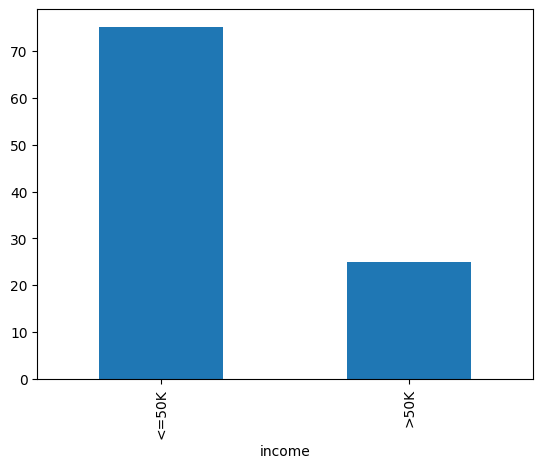

In [106]:
print(df_clean['income'].value_counts(normalize=True))
df_clean['income'].value_counts(normalize=True).mul(100).plot(kind='bar')

# **Multinomial Naive Bayes** : Converting all features into categorical form

* Multinomial Naive Bayes requires all input features to be **categorical** or **discrete**.
* Since our dataset includes several **continuous numerical features**, we first **discretize** these numeric columns using appropriate binning techniques.
* The result is stored in a **df_discretized**, where all features are now categorical

In [107]:
import warnings
warnings.filterwarnings("ignore")


categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)

from sklearn.preprocessing import KBinsDiscretizer

# Discretize numerical features
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
num_discretized = discretizer.fit_transform(df_clean[numerical_cols])

# Create DataFrame for discretized numeric features
df_discretized_num = pd.DataFrame(num_discretized,
                                   columns=[f"{col}_bin" for col in numerical_cols],
                                   index=df_clean.index)

# Drop original numeric features and join discretized ones
df_discretized = df_clean.drop(columns=numerical_cols)
df_discretized = pd.concat([df_discretized, df_discretized_num], axis=1)

print("\n Discretized numeric features stored in df_discretized")
df_discretized





Categorical Features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
Numerical Features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

 Discretized numeric features stored in df_discretized


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income,age_bin,fnlwgt_bin,education-num_bin,capital-gain_bin,capital-loss_bin,hours-per-week_bin
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K,2.0,0.0,3.0,0.0,0.0,2.0
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K,4.0,0.0,3.0,0.0,0.0,0.0
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K,2.0,3.0,1.0,0.0,0.0,2.0
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K,4.0,3.0,0.0,0.0,0.0,2.0
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K,1.0,4.0,3.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,United-States,<=50K,1.0,3.0,2.0,0.0,0.0,1.0
32557,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States,>50K,2.0,1.0,1.0,0.0,0.0,2.0
32558,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,United-States,<=50K,4.0,1.0,1.0,0.0,0.0,2.0
32559,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,United-States,<=50K,0.0,3.0,1.0,0.0,0.0,0.0


# **Integer encoding for all features**

In [108]:
from sklearn.preprocessing import OrdinalEncoder

# Copy from df_discretized
df_discretized_ordinal = df_discretized.copy()

# Identify which columns are still object (i.e., the original categoricals)
object_cols = df_discretized_ordinal.select_dtypes(include='object').columns.tolist()

# Ordinal encode only those object columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_discretized_ordinal[object_cols] = encoder.fit_transform(df_discretized_ordinal[object_cols])

df_discretized_ordinal


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income,age_bin,fnlwgt_bin,education-num_bin,capital-gain_bin,capital-loss_bin,hours-per-week_bin
0,5.0,9.0,4.0,0.0,1.0,4.0,1.0,38.0,0.0,2.0,0.0,3.0,0.0,0.0,2.0
1,4.0,9.0,2.0,3.0,0.0,4.0,1.0,38.0,0.0,4.0,0.0,3.0,0.0,0.0,0.0
2,2.0,11.0,0.0,5.0,1.0,4.0,1.0,38.0,0.0,2.0,3.0,1.0,0.0,0.0,2.0
3,2.0,1.0,2.0,5.0,0.0,2.0,1.0,38.0,0.0,4.0,3.0,0.0,0.0,0.0,2.0
4,2.0,9.0,2.0,9.0,5.0,2.0,0.0,4.0,0.0,1.0,4.0,3.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,2.0,7.0,2.0,12.0,5.0,4.0,0.0,38.0,0.0,1.0,3.0,2.0,0.0,0.0,1.0
32557,2.0,11.0,2.0,6.0,0.0,4.0,1.0,38.0,1.0,2.0,1.0,1.0,0.0,0.0,2.0
32558,2.0,11.0,6.0,0.0,4.0,4.0,0.0,38.0,0.0,4.0,1.0,1.0,0.0,0.0,2.0
32559,2.0,11.0,4.0,0.0,3.0,4.0,1.0,38.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0


# **Training Multinomial Naive Bayes with integer encoded features and Model Evaluation**

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import numpy as np




X = df_discretized_ordinal.drop(columns=["income"]).copy()
y = df_discretized_ordinal["income"].astype(int)

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42
)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Probabilities for AUC
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

# Metrics
train_acc  = accuracy_score(y_train, y_train_pred)
test_acc   = accuracy_score(y_test, y_test_pred)

train_prec = precision_score(y_train, y_train_pred, zero_division=0)
test_prec  = precision_score(y_test, y_test_pred, zero_division=0)

train_rec  = recall_score(y_train, y_train_pred, zero_division=0)
test_rec   = recall_score(y_test, y_test_pred, zero_division=0)

train_f1   = f1_score(y_train, y_train_pred, zero_division=0)
test_f1    = f1_score(y_test, y_test_pred, zero_division=0)

train_auc  = roc_auc_score(y_train, y_train_prob)
test_auc   = roc_auc_score(y_test, y_test_prob)

# Print results
print("\nMultinomialNB using 80/20 Split:")
print("-" * 40)
print(f"Train Accuracy:  {train_acc:.4f}")
print(f"Train Precision: {train_prec:.4f}")
print(f"Train Recall:    {train_rec:.4f}")
print(f"Train F1 Score:  {train_f1:.4f}")
print(f"Train AUC:       {train_auc:.4f}")
print("-" * 40)
print(f"Test Accuracy:   {test_acc:.4f}")
print(f"Test Precision:  {test_prec:.4f}")
print(f"Test Recall:     {test_rec:.4f}")
print(f"Test F1 Score:   {test_f1:.4f}")
print(f"Test AUC:        {test_auc:.4f}")
print("-" * 40)

# Classification report
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=['<=50K', '>50K']))



MultinomialNB using 80/20 Split:
----------------------------------------
Train Accuracy:  0.7774
Train Precision: 0.5449
Train Recall:    0.6429
Train F1 Score:  0.5898
Train AUC:       0.7896
----------------------------------------
Test Accuracy:   0.7820
Test Precision:  0.5554
Test Recall:     0.6245
Test F1 Score:   0.5879
Test AUC:        0.7859
----------------------------------------

Classification Report (Test):
              precision    recall  f1-score   support

       <=50K       0.87      0.83      0.85      4531
        >50K       0.56      0.62      0.59      1502

    accuracy                           0.78      6033
   macro avg       0.71      0.73      0.72      6033
weighted avg       0.79      0.78      0.79      6033



# **One Hot Encoding for all features**

In [110]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Separate features and target
X_cat = df_discretized.drop(columns=['income']).copy()
y_ohe = df_discretized['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)


# One-hot encode only the feature columns
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_onehot = ohe.fit_transform(X_cat)

# Create final DataFrame with one-hot encoded features
df_discretized_onehot = pd.DataFrame(
    X_onehot,
    columns=ohe.get_feature_names_out(X_cat.columns),
    index=X_cat.index
)


df_discretized_onehot


,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,...,education-num_bin_0.0,education-num_bin_1.0,education-num_bin_2.0,education-num_bin_3.0,capital-gain_bin_0.0,capital-loss_bin_0.0,hours-per-week_bin_0.0,hours-per-week_bin_1.0,hours-per-week_bin_2.0,hours-per-week_bin_3.0
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
32557,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
32558,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
32559,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


# **Training Multinomial Naive Bayes with One Hot Enoded features and Model Evaluation**

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import numpy as np




X = df_discretized_onehot

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_ohe, test_size=0.2, shuffle=True, stratify=y_ohe,random_state=42
)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Probabilities for AUC
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

# Metrics
train_acc  = accuracy_score(y_train, y_train_pred)
test_acc   = accuracy_score(y_test, y_test_pred)

train_prec = precision_score(y_train, y_train_pred, zero_division=0)
test_prec  = precision_score(y_test, y_test_pred, zero_division=0)

train_rec  = recall_score(y_train, y_train_pred, zero_division=0)
test_rec   = recall_score(y_test, y_test_pred, zero_division=0)

train_f1   = f1_score(y_train, y_train_pred, zero_division=0)
test_f1    = f1_score(y_test, y_test_pred, zero_division=0)

train_auc  = roc_auc_score(y_train, y_train_prob)
test_auc   = roc_auc_score(y_test, y_test_prob)

# Print results
print("\nMultinomialNB using 80/20 Split:")
print("-" * 40)
print(f"Train Accuracy:  {train_acc:.4f}")
print(f"Train Precision: {train_prec:.4f}")
print(f"Train Recall:    {train_rec:.4f}")
print(f"Train F1 Score:  {train_f1:.4f}")
print(f"Train AUC:       {train_auc:.4f}")
print("-" * 40)
print(f"Test Accuracy:   {test_acc:.4f}")
print(f"Test Precision:  {test_prec:.4f}")
print(f"Test Recall:     {test_rec:.4f}")
print(f"Test F1 Score:   {test_f1:.4f}")
print(f"Test AUC:        {test_auc:.4f}")
print("-" * 40)

# Classification report
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=['<=50K', '>50K']))



MultinomialNB using 80/20 Split:
----------------------------------------
Train Accuracy:  0.8055
Train Precision: 0.5832
Train Recall:    0.7654
Train F1 Score:  0.6620
Train AUC:       0.8814
----------------------------------------
Test Accuracy:   0.8076
Test Precision:  0.5888
Test Recall:     0.7530
Test F1 Score:   0.6608
Test AUC:        0.8831
----------------------------------------

Classification Report (Test):
              precision    recall  f1-score   support

       <=50K       0.91      0.83      0.87      4531
        >50K       0.59      0.75      0.66      1502

    accuracy                           0.81      6033
   macro avg       0.75      0.79      0.76      6033
weighted avg       0.83      0.81      0.81      6033



# **Gaussian Naive Bayes**

* Gaussian Naive Bayes is designed for continuous numeric features, assuming each follows a Gaussian (normal) distribution within each class.

* Therefore, we keep all numeric features as they are (no discretization or binning).

* Since our dataset also contains categorical features, we convert them into numeric form using encoding techniques (Integer or One-Hot Encoding), making them compatible with GaussianNB.

## **Integer Encoding of categorical features**

In [112]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# Identify target column
target_col = "income"

# Separate categorical and numerical columns (excluding target)
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("Categorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)

# Ordinal encode categorical feature columns only
encoder = OrdinalEncoder()
cat_encoded = encoder.fit_transform(df_clean[categorical_cols])

# Create DataFrame for encoded categorical features
df_encoded_cat = pd.DataFrame(
    cat_encoded,
    columns=[f"{col}_ord" for col in categorical_cols],
    index=df_clean.index
)

# Combine encoded categorical + original numeric features + target
df_encoded = pd.concat(
    [df_encoded_cat, df_clean[numerical_cols], df_clean[[target_col]]],
    axis=1
)

print("\n Integer-encoded categorical + numeric features stored in df_encoded")
df_encoded.head()


Categorical Features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numerical Features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

 Integer-encoded categorical + numeric features stored in df_encoded


,workclass_ord,education_ord,marital-status_ord,occupation_ord,relationship_ord,race_ord,sex_ord,native-country_ord,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
0,5.0,9.0,4.0,0.0,1.0,4.0,1.0,38.0,39,77516,13,2174,0,40,<=50K
1,4.0,9.0,2.0,3.0,0.0,4.0,1.0,38.0,50,83311,13,0,0,13,<=50K
2,2.0,11.0,0.0,5.0,1.0,4.0,1.0,38.0,38,215646,9,0,0,40,<=50K
3,2.0,1.0,2.0,5.0,0.0,2.0,1.0,38.0,53,234721,7,0,0,40,<=50K
4,2.0,9.0,2.0,9.0,5.0,2.0,0.0,4.0,28,338409,13,0,0,40,<=50K


# **Training Gaussian NB with integer encoding for categorical features**

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import numpy as np

# Prepare features and target

X = df_encoded.drop(columns=["income"]).copy()
y = df_encoded["income"].map({"<=50K": 0, ">50K": 1}).astype(int)




# Split data (80/20 split, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)


# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
# X_test[numerical_cols]  = scaler.transform(X_test[numerical_cols])


# Train GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Probabilities for AUC
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

# Metrics
train_acc  = accuracy_score(y_train, y_train_pred)
test_acc   = accuracy_score(y_test, y_test_pred)

train_prec = precision_score(y_train, y_train_pred, zero_division=0)
test_prec  = precision_score(y_test, y_test_pred, zero_division=0)

train_rec  = recall_score(y_train, y_train_pred, zero_division=0)
test_rec   = recall_score(y_test, y_test_pred, zero_division=0)

train_f1   = f1_score(y_train, y_train_pred, zero_division=0)
test_f1    = f1_score(y_test, y_test_pred, zero_division=0)

train_auc  = roc_auc_score(y_train, y_train_prob)
test_auc   = roc_auc_score(y_test, y_test_prob)

# Print results
print("\nGaussianNB using 80/20 Split:")
print("-" * 40)
print(f"Train Accuracy:  {train_acc:.4f}")
print(f"Train Precision: {train_prec:.4f}")
print(f"Train Recall:    {train_rec:.4f}")
print(f"Train F1 Score:  {train_f1:.4f}")
print(f"Train AUC:       {train_auc:.4f}")
print("-" * 40)
print(f"Test Accuracy:   {test_acc:.4f}")
print(f"Test Precision:  {test_prec:.4f}")
print(f"Test Recall:     {test_rec:.4f}")
print(f"Test F1 Score:   {test_f1:.4f}")
print(f"Test AUC:        {test_auc:.4f}")
print("-" * 40)

# Classification report
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=['<=50K', '>50K']))



GaussianNB using 80/20 Split:
----------------------------------------
Train Accuracy:  0.7878
Train Precision: 0.6544
Train Recall:    0.3130
Train F1 Score:  0.4235
Train AUC:       0.8283
----------------------------------------
Test Accuracy:   0.7865
Test Precision:  0.6569
Test Recall:     0.2983
Test F1 Score:   0.4103
Test AUC:        0.8289
----------------------------------------

Classification Report (Test):
              precision    recall  f1-score   support

       <=50K       0.80      0.95      0.87      4531
        >50K       0.66      0.30      0.41      1502

    accuracy                           0.79      6033
   macro avg       0.73      0.62      0.64      6033
weighted avg       0.77      0.79      0.76      6033



## **One hot encoding for categorical features**

In [114]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

target_col = "income"

# Separate categorical and numerical columns (excluding target)
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("Categorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)

# One-Hot Encode categorical columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_encoded = encoder.fit_transform(df_clean[categorical_cols])

df_encoded_cat = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df_clean.index
)

# Combine encoded categorical + original numeric + target
df_encoded_ohe = pd.concat(
    [df_encoded_cat, df_clean[numerical_cols], df_clean[[target_col]]],
    axis=1
)

print("\n One-hot encoded categorical + original numeric features stored in df_encoded_ohe")
df_encoded_ohe.head()


Categorical Features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numerical Features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

 One-hot encoded categorical + original numeric features stored in df_encoded_ohe


,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,...,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,39,77516,13,2174,0,40,<=50K
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,50,83311,13,0,0,13,<=50K
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,38,215646,9,0,0,40,<=50K
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,53,234721,7,0,0,40,<=50K
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,28,338409,13,0,0,40,<=50K


# **Training Gaussian NB with one hot encoding for categorical features**

In [115]:

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)


# Features (all columns except the target)
X = df_encoded_ohe.drop(columns=["income"]).copy()

# Target variable (convert to numeric 0/1)
y = df_encoded_ohe["income"].map({"<=50K": 0, ">50K": 1}).astype(int)



# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y,random_state=42
)

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
# X_test[numerical_cols]  = scaler.transform(X_test[numerical_cols])


# Train model
model = GaussianNB()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Probabilities for AUC
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

# Metrics
train_acc  = accuracy_score(y_train, y_train_pred)
test_acc   = accuracy_score(y_test, y_test_pred)

train_prec = precision_score(y_train, y_train_pred, zero_division=0)
test_prec  = precision_score(y_test, y_test_pred, zero_division=0)

train_rec  = recall_score(y_train, y_train_pred, zero_division=0)
test_rec   = recall_score(y_test, y_test_pred, zero_division=0)

train_f1   = f1_score(y_train, y_train_pred, zero_division=0)
test_f1    = f1_score(y_test, y_test_pred, zero_division=0)

train_auc  = roc_auc_score(y_train, y_train_prob)
test_auc   = roc_auc_score(y_test, y_test_prob)

# Print results
print("\n Gaussian NB using 80/20 Split:")
print("-" * 40)
print(f"Train Accuracy:  {train_acc:.4f}")
print(f"Train Precision: {train_prec:.4f}")
print(f"Train Recall:    {train_rec:.4f}")
print(f"Train F1 Score:  {train_f1:.4f}")
print(f"Train AUC:       {train_auc:.4f}")
print("-" * 40)
print(f"Test Accuracy:   {test_acc:.4f}")
print(f"Test Precision:  {test_prec:.4f}")
print(f"Test Recall:     {test_rec:.4f}")
print(f"Test F1 Score:   {test_f1:.4f}")
print(f"Test AUC:        {test_auc:.4f}")
print("-" * 40)

# Classification report
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=['<=50K', '>50K']))




 Gaussian NB using 80/20 Split:
----------------------------------------
Train Accuracy:  0.7878
Train Precision: 0.6538
Train Recall:    0.3132
Train F1 Score:  0.4235
Train AUC:       0.8297
----------------------------------------
Test Accuracy:   0.7873
Test Precision:  0.6617
Test Recall:     0.2983
Test F1 Score:   0.4112
Test AUC:        0.8280
----------------------------------------

Classification Report (Test):
              precision    recall  f1-score   support

       <=50K       0.80      0.95      0.87      4531
        >50K       0.66      0.30      0.41      1502

    accuracy                           0.79      6033
   macro avg       0.73      0.62      0.64      6033
weighted avg       0.77      0.79      0.76      6033



# **Final Comparison: Multinomial Naive Bayes vs Gaussian Naive Bayes**

| Model                       | Encoding Type    | Test Accuracy | Precision  | Recall     | F1 Score   | AUC        |
| :-------------------------- | :--------------- | :------------ | :--------- | :--------- | :--------- | :--------- |
| **Multinomial Naive Bayes** | Ordinal Encoding | 0.7820    | 0.5554     | 0.6245     | 0.5879     | 0.7859     |
| **Multinomial Naive Bayes** | One-Hot Encoding | **0.8076**    | 0.5888     | **0.7530** | **0.6608** | **0.8831** |
| **Gaussian Naive Bayes**    | Ordinal Encoding | 0.7865        | 0.6569     | 0.2983     | 0.4103     | 0.8289     |
| **Gaussian Naive Bayes**    | One-Hot Encoding | 0.7873        | **0.6617** | 0.2983     | 0.4112     | 0.8280     |


# **Observations**
1. **Multinomial Naive Bayes with One-Hot Encoding** delivers the best overall performance, achieving the highest recall, F1 score, and AUC, showing that it models categorical relationships more effectively.

2. **Gaussian Naive Bayes** performs similarly in accuracy but struggles with recall, indicating its Gaussian assumption is less suited for primarily categorical or discretized data.
